In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("/content/bank-additional-full.csv", sep=";")  # change path

target = "y"

X = df.drop(columns=target)
y = df[target]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# Fill missing values
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("missing")

In [4]:
y.value_counts()

,count
y,
no,36548
yes,4640


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
def make_preprocessor(scaler=None, use_pca=False):
    num_steps = []
    if scaler:
        num_steps.append(("scaler", scaler))
    if use_pca:
        num_steps.append(("pca", PCA(n_components=0.95, random_state=42)))

    numeric_pipe = Pipeline(num_steps) if num_steps else "passthrough"

    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ])


In [7]:
models = {
    "logreg": LogisticRegression(max_iter=500, solver="saga", n_jobs=-1),
    "rf": RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42),
    "hgb": HistGradientBoostingClassifier(max_iter=200, random_state=42),
    "svc": SVC(kernel="rbf", probability=True, random_state=42),
    "nb": GaussianNB()
}


In [8]:
pipelines = {}

scalers = [("std", StandardScaler()), ("minmax", MinMaxScaler()), ("noprep", None)]
use_pca_options = [False, True]

for algo_name in ["logreg", "rf", "hgb", "svc", "nb"]:
    for prep_name, scaler in scalers:
        # Skip PCA for noprep
        if prep_name == "noprep":
            pipelines[f"{prep_name}_{algo_name}"] = Pipeline([
                ("prep", make_preprocessor()),
                ("model", models[algo_name])
            ])
        else:
            # Add standard and minmax
            pipelines[f"{prep_name}_{algo_name}"] = Pipeline([
                ("prep", make_preprocessor(scaler)),
                ("model", models[algo_name])
            ])
            # Add PCA variant
            pipelines[f"pca_{algo_name}"] = Pipeline([
                ("prep", make_preprocessor(scaler, use_pca=True)),
                ("model", models[algo_name])
            ])


In [9]:
def train_and_score(name, pipe):
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, average='macro'),
        "recall": recall_score(y_test, preds, average='macro'),
        "f1": f1_score(y_test, preds, average='macro')
    }

results = Parallel(n_jobs=-1)(
    delayed(train_and_score)(name, pipe)
    for name, pipe in pipelines.items()
)

df_results = pd.DataFrame(results).set_index("model")

# Composite score
df_results["composite"] = (
    0.35 * df_results["f1"] +
    0.25 * df_results["precision"] +
    0.25 * df_results["recall"] +
    0.15 * df_results["accuracy"]
)

df_results = round(df_results.sort_values("composite", ascending=False),4)
print(df_results)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


               accuracy  precision  recall      f1  composite
model                                                        
noprep_hgb       0.9218     0.8147  0.7692  0.7895     0.8105
std_hgb          0.9218     0.8147  0.7692  0.7895     0.8105
minmax_hgb       0.9218     0.8147  0.7692  0.7895     0.8105
noprep_rf        0.9195     0.8240  0.7279  0.7646     0.7935
minmax_rf        0.9195     0.8240  0.7279  0.7646     0.7935
std_rf           0.9193     0.8231  0.7273  0.7639     0.7929
std_logreg       0.9164     0.8208  0.7064  0.7469     0.7807
std_svc          0.9154     0.8199  0.6997  0.7411     0.7766
minmax_logreg    0.9147     0.8231  0.6894  0.7330     0.7719
noprep_logreg    0.9085     0.8075  0.6582  0.7011     0.7481
noprep_nb        0.8681     0.6846  0.7210  0.7001     0.7266
pca_hgb          0.9011     0.7740  0.6347  0.6723     0.7227
pca_rf           0.9002     0.7682  0.6357  0.6724     0.7213
minmax_svc       0.9028     0.8222  0.6018  0.6392     0.7151
std_nb  

/tmp/ipykernel_2155/2280932727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y=df_results["composite"], palette="viridis")


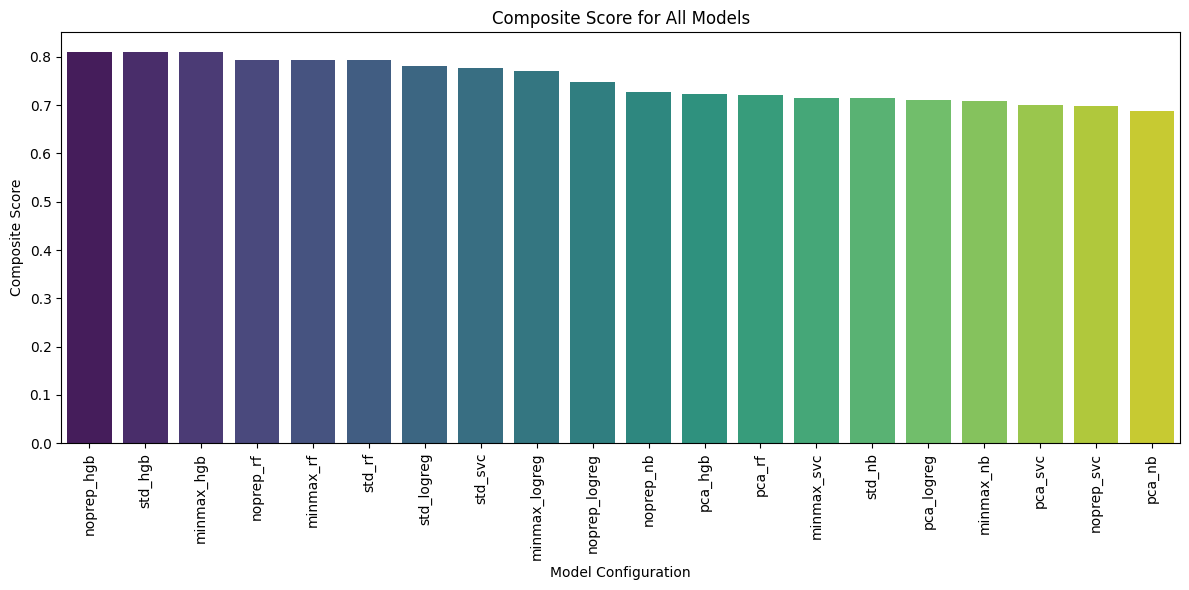

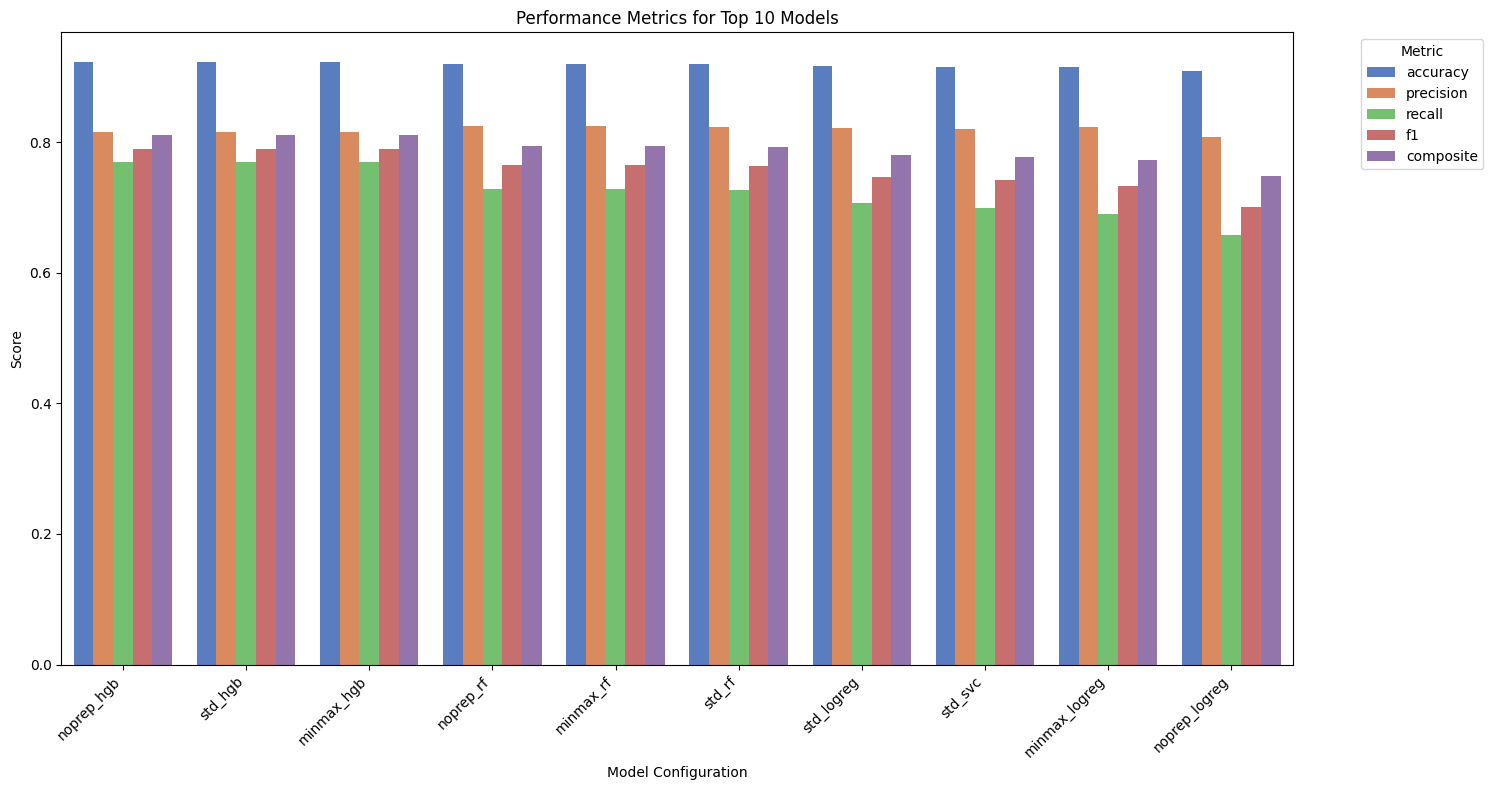

In [10]:


# Plotting the composite score for all models
plt.figure(figsize=(12, 6))
sns.barplot(x=df_results.index, y=df_results["composite"], palette="viridis")
plt.xticks(rotation=90)
plt.title("Composite Score for All Models")
plt.ylabel("Composite Score")
plt.xlabel("Model Configuration")
plt.tight_layout()
plt.show()

# Selecting top 10 models based on composite score
top_10_models = df_results.head(10)

# Melt the DataFrame for easier plotting of multiple metrics
df_melted = top_10_models[['accuracy', 'precision', 'recall', 'f1', 'composite']].reset_index().melt(
    id_vars='model', var_name='metric', value_name='score'
)

# Plotting individual metrics for top 10 models
plt.figure(figsize=(15, 8))
sns.barplot(x='model', y='score', hue='metric', data=df_melted, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title("Performance Metrics for Top 10 Models")
plt.ylabel("Score")
plt.xlabel("Model Configuration")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the composite score for all models
plt.figure(figsize=(12, 6))
sns.barplot(x=df_results.index, y=df_results["composite"], palette="viridis")
plt.xticks(rotation=90)
plt.title("Composite Score for All Models")
plt.ylabel("Composite Score")
plt.xlabel("Model Configuration")
plt.tight_layout()
plt.show()

# Selecting top 10 models based on composite score
top_10_models = df_results.head(10)

# Melt the DataFrame for easier plotting of multiple metrics
df_melted = top_10_models[['accuracy', 'precision', 'recall', 'f1', 'composite']].reset_index().melt(
    id_vars='model', var_name='metric', value_name='score'
)

# Plotting individual metrics for top 10 models
plt.figure(figsize=(15, 8))
sns.barplot(x='model', y='score', hue='metric', data=df_melted, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title("Performance Metrics for Top 10 Models")
plt.ylabel("Score")
plt.xlabel("Model Configuration")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

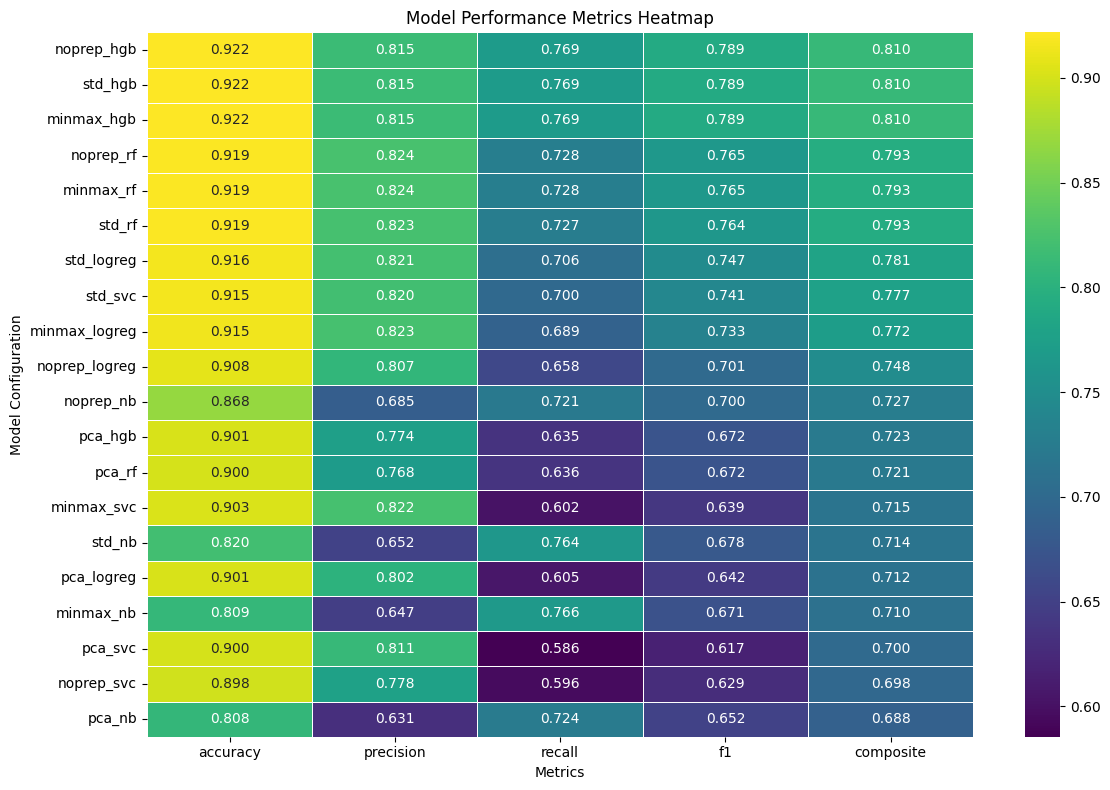

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_results, annot=True, cmap="viridis", fmt=".3f", linewidths=.5)
plt.title("Model Performance Metrics Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Model Configuration")
plt.tight_layout()
plt.show()